<a href="https://colab.research.google.com/github/MaheeshVarma-Ugge/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
!pip install xgboost

# **1. Load dataset**

In [99]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [101]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [102]:
df.shape

(7043, 21)

# **Data Validation**

# **Missing values**

In [103]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# **Infinite values**

In [104]:
print(df.isin([np.inf, -np.inf]).any())

customerID          False
gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges        False
Churn               False
dtype: bool


# **duplicate values**

In [105]:
print("Duplicate Rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After Removing:")
print(df.duplicated().sum())

Duplicate Rows:
0
Duplicate Rows After Removing:
0


# **NaN values**

In [106]:
nan_counts = df.isnull().sum()
nan_counts = nan_counts[nan_counts > 0]

print("NaN counts per column:")
print(nan_counts)


NaN counts per column:
Series([], dtype: int64)


# **Encoding Categorical Variables**

In [107]:
print(df.select_dtypes(include="object").columns)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [108]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [109]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [110]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print(df.head())

   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0        5375       0              0        1           0       1   
1        3962       1              0        0           0      34   
2        2564       1              0        0           0       2   
3        5535       1              0        0           0      45   
4        6511       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   


# **Feature Scaling**

In [111]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [113]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0.911890,-1.009559,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.062723,-1.183234,-0.918838,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,-1.160323,-0.994242
1,0.216906,0.990532,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-0.991588,-1.183234,1.407321,-1.029919,1.245111,-0.925262,-1.113495,-1.121405,0.371271,-1.205113,1.334863,-0.259629,-0.173244
2,-0.470701,0.990532,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,-1.183234,1.407321,1.242550,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,1.334863,-0.362660,-0.959674
3,0.990587,0.990532,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,0.062723,-1.183234,1.407321,-1.029919,1.245111,1.396299,-1.113495,-1.121405,0.371271,-1.205113,-1.474052,-0.746535,-0.194766
4,1.470632,-1.009559,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,-0.991588,0.172250,-0.918838,-1.029919,-1.027910,-0.925262,-1.113495,-1.121405,-0.828207,0.829798,0.398558,0.197365,-0.940470


#  **Exploratory Data Analysis**

# **Churn Distribution**

In [114]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [115]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


# **Relationship Between Tenure and Churn**

In [116]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
0,37.569965
1,17.979133


In [117]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


# **Impact of Monthly Charges on Churn**

In [118]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
0,61.265124
1,74.441332


# **Subscription-wise Churn Analysis**

In [119]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,0,1
Contract,,
0,2220,1655
1,1307,166
2,1647,48


In [120]:
df.groupby("Contract")["Churn"].value_counts()

Contract  Churn
0         0        2220
          1        1655
1         0        1307
          1         166
2         0        1647
          1          48
Name: count, dtype: int64

# **Correlation Between Features**

In [121]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
numeric_df.corr()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,1.000000,0.006288,-0.002074,-0.026729,-0.012823,0.008035,-0.006483,0.004316,-0.012407,0.013292,...,-0.006918,0.001140,-0.007777,-0.016746,0.015028,-0.001945,0.011604,-0.003916,-0.000019,-0.017447
gender,0.006288,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.006739,-0.000863,-0.015017,...,0.000549,-0.006825,-0.006421,-0.008743,0.000126,-0.011754,0.017352,-0.014569,-0.000002,-0.008612
SeniorCitizen,-0.002074,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.146185,-0.032310,-0.128221,...,-0.021398,-0.151268,0.030776,0.047266,-0.142554,0.156530,-0.038551,0.220173,0.102652,0.150889
Partner,-0.026729,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,0.142410,0.000891,0.150828,...,0.166330,0.126733,0.137341,0.129574,0.294806,-0.014877,-0.154798,0.096848,0.318364,-0.150448
Dependents,-0.012823,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.024991,0.044590,0.152166,...,0.080537,0.133524,0.046885,0.021321,0.243187,-0.111377,-0.040292,-0.113890,0.063593,-0.164221
tenure,0.008035,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.343032,-0.030359,0.325468,...,0.371105,0.322942,0.289373,0.296866,0.671607,0.006152,-0.370436,0.247900,0.825464,-0.352229
PhoneService,-0.006483,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,-0.020538,0.387436,-0.015198,...,0.003727,-0.019158,0.055353,0.043870,0.002247,0.016505,-0.004184,0.247398,0.113013,0.011942
MultipleLines,0.004316,-0.006739,0.146185,0.142410,-0.024991,0.343032,-0.020538,1.000000,-0.109216,0.007141,...,0.122318,0.011466,0.175059,0.180957,0.110842,0.165146,-0.176793,0.433576,0.452849,0.038037
InternetService,-0.012407,-0.000863,-0.032310,0.000891,0.044590,-0.030359,0.387436,-0.109216,1.000000,-0.028416,...,0.044944,-0.026047,0.107417,0.098350,0.099721,-0.138625,0.086140,-0.323260,-0.175588,-0.047291
OnlineSecurity,0.013292,-0.015017,-0.128221,0.150828,0.152166,0.325468,-0.015198,0.007141,-0.028416,1.000000,...,0.175985,0.285028,0.044669,0.055954,0.374416,-0.157641,-0.096726,-0.053878,0.253935,-0.289309


# **Data Visualization**

# **Churn Distribution Pie Chart**

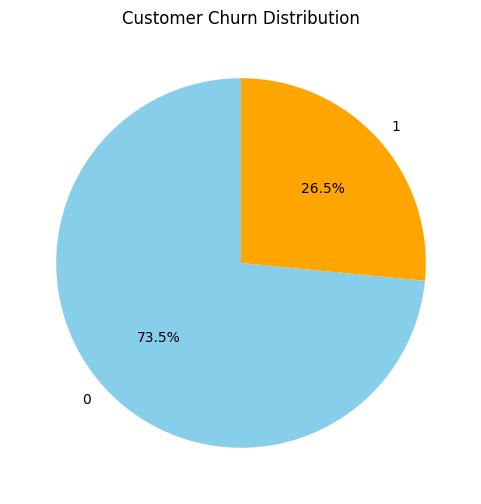

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=["skyblue","orange"],
    startangle=90
)

plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

# **Bar Chart of Churn by Contract**

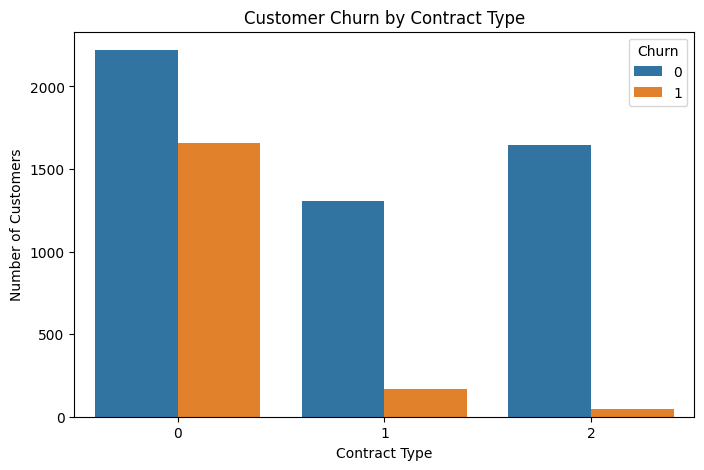

In [123]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

# **Correlation Heatmap**

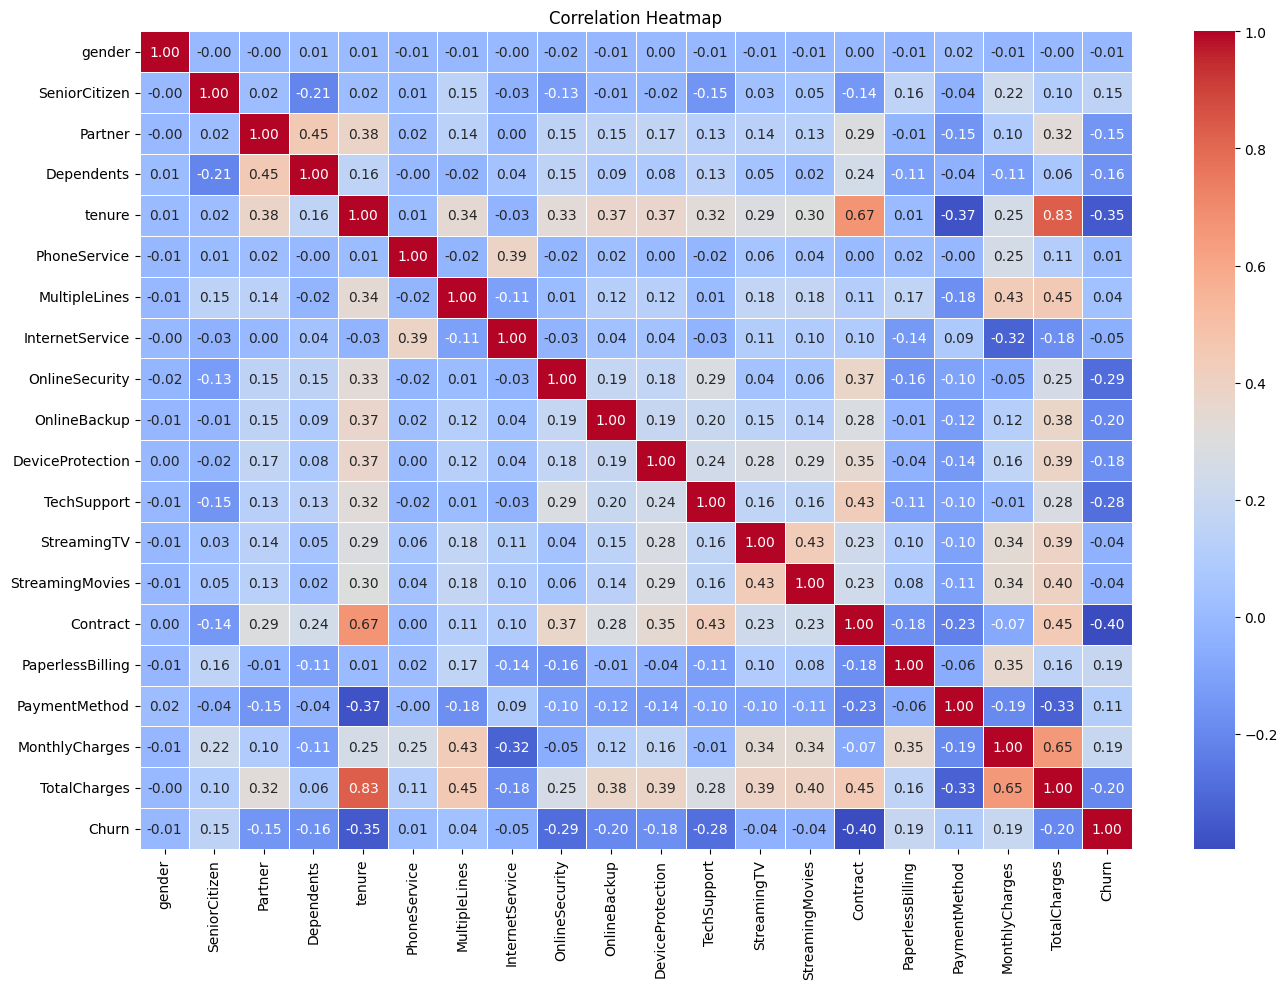

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove customerID if it exists
if "customerID" in df.columns:
    heatmap_df = df.drop("customerID", axis=1)
else:
    heatmap_df = df.copy()

# Select only numeric columns
numeric_df = heatmap_df.select_dtypes(include=["int64", "float64"])

# Create the heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# **Histogram of Monthly Charges**

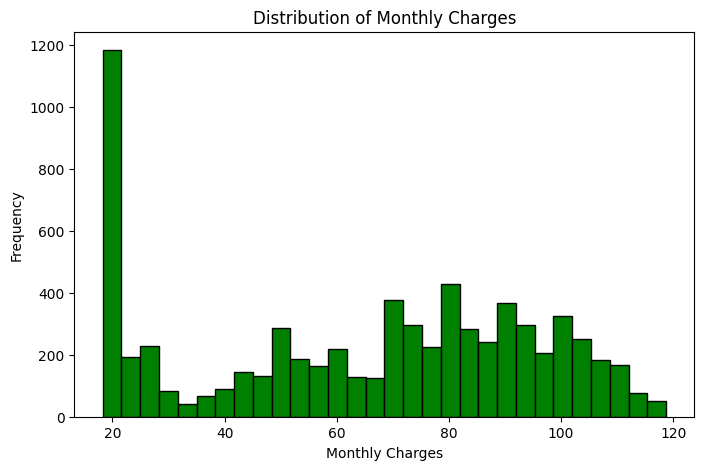

In [125]:
plt.figure(figsize=(8,5))

plt.hist(
    df["MonthlyCharges"],
    bins=30,
    color="green",
    edgecolor="black"
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

# **Tenure vs Churn**

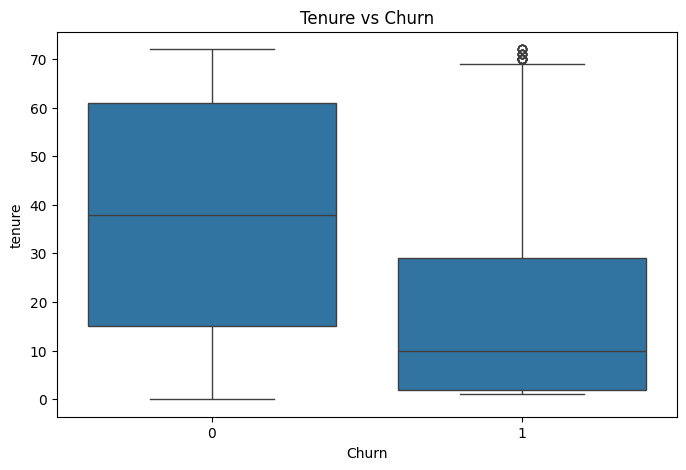

In [126]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")

plt.show()

# **Monthly Charges vs Churn**

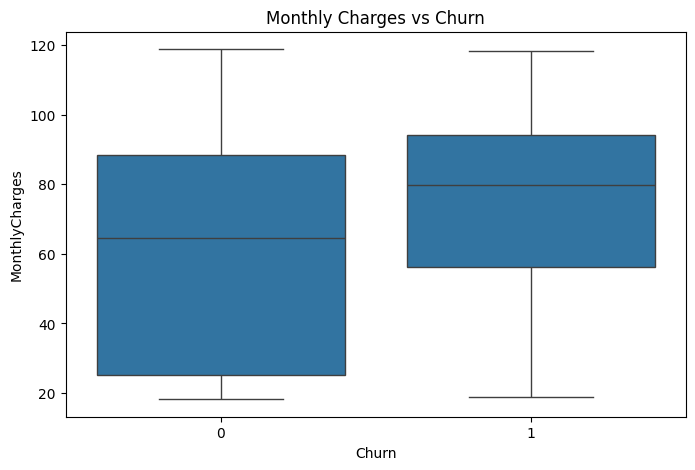

In [127]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

# **Split Data into Features and Target**

In [128]:
# Features (X) and Target (y)
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)



Features Shape: (7043, 20)
Target Shape: (7043,)


In [129]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 20)
y_train shape: (5634,)
X_test shape: (1409, 20)
y_test shape: (1409,)


# **Choose and Train the Model**

In [130]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# -----------------------------
# Train Models
# -----------------------------

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# -----------------------------
# Evaluation Function
# -----------------------------

def evaluate_model(y_true, y_pred):
    return [
        round(accuracy_score(y_true, y_pred), 4),
        round(precision_score(y_true, y_pred), 4),
        round(recall_score(y_true, y_pred), 4),
        round(f1_score(y_true, y_pred), 4),
        confusion_matrix(y_true, y_pred).tolist()
    ]

# -----------------------------
# Create Comparison Table
# -----------------------------

results = pd.DataFrame(
    [
        ["Logistic Regression"] + evaluate_model(y_test, lr_pred),
        ["Random Forest Classifier"] + evaluate_model(y_test, rf_pred),
        ["Decision Tree Classifier"] + evaluate_model(y_test, dt_pred)
    ],
    columns=[
        "Model",
        "Accuracy Score",
        "Precision",
        "Recall",
        "F1 Score",
        "Confusion Matrix"
    ]
)

display(results)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy Score,Precision,Recall,F1 Score,Confusion Matrix
0,Logistic Regression,0.7921,0.6254,0.5401,0.5796,"[[914, 121], [172, 202]]"
1,Random Forest Classifier,0.7878,0.6271,0.4947,0.5531,"[[925, 110], [189, 185]]"
2,Decision Tree Classifier,0.7303,0.4925,0.5294,0.5103,"[[831, 204], [176, 198]]"


In [153]:
import pandas as pd

print("=" * 50)
print("      CUSTOMER CHURN PREDICTION SYSTEM")
print("=" * 50)

# Function to validate integer input
def get_valid_input(prompt, valid_values):
    while True:
        try:
            value = int(input(prompt))
            if value in valid_values:
                return value
            else:
                print(f"❌ Invalid input! Please enter one of {valid_values}.")
        except ValueError:
            print("❌ Invalid input! Please enter a valid integer.")

# Function to validate positive float input
def get_positive_float(prompt):
    while True:
        try:
            value = float(input(prompt))
            if value >= 0:
                return value
            else:
                print("❌ Value cannot be negative.")
        except ValueError:
            print("❌ Invalid input! Please enter a numeric value.")

# Function to validate positive integer input
def get_positive_int(prompt):
    while True:
        try:
            value = int(input(prompt))
            if value >= 0:
                return value
            else:
                print("❌ Value cannot be negative.")
        except ValueError:
            print("❌ Invalid input! Please enter a valid integer.")

# Collect user inputs
gender = get_valid_input("Gender (0=Female, 1=Male): ", [0,1])
senior = get_valid_input("Senior Citizen (0=No, 1=Yes): ", [0,1])
partner = get_valid_input("Partner (0=No, 1=Yes): ", [0,1])
dependents = get_valid_input("Dependents (0=No, 1=Yes): ", [0,1])

tenure = get_positive_int("Tenure (Months): ")

phone = get_valid_input("Phone Service (0=No, 1=Yes): ", [0,1])
multiple = get_valid_input("Multiple Lines (0=No, 1=No Phone Service, 2=Yes): ", [0,1,2])
internet = get_valid_input("Internet Service (0=DSL, 1=Fiber Optic, 2=No): ", [0,1,2])
security = get_valid_input("Online Security (0=No, 1=No Internet, 2=Yes): ", [0,1,2])
backup = get_valid_input("Online Backup (0=No, 1=No Internet, 2=Yes): ", [0,1,2])
device = get_valid_input("Device Protection (0=No, 1=No Internet, 2=Yes): ", [0,1,2])
tech = get_valid_input("Tech Support (0=No, 1=No Internet, 2=Yes): ", [0,1,2])
tv = get_valid_input("Streaming TV (0=No, 1=No Internet, 2=Yes): ", [0,1,2])
movies = get_valid_input("Streaming Movies (0=No, 1=No Internet, 2=Yes): ", [0,1,2])
contract = get_valid_input("Contract (0=Month-to-Month, 1=One Year, 2=Two Year): ", [0,1,2])
paper = get_valid_input("Paperless Billing (0=No, 1=Yes): ", [0,1])
payment = get_valid_input("Payment Method (0=Bank Transfer, 1=Credit Card, 2=Electronic Check, 3=Mailed Check): ", [0,1,2,3])

monthly = get_positive_float("Monthly Charges: ")
total = get_positive_float("Total Charges: ")

# Create DataFrame with the same feature names used for training
sample = pd.DataFrame({
    "customerID": [0],
    "gender": [gender],
    "SeniorCitizen": [senior],
    "Partner": [partner],
    "Dependents": [dependents],
    "tenure": [tenure],
    "PhoneService": [phone],
    "MultipleLines": [multiple],
    "InternetService": [internet],
    "OnlineSecurity": [security],
    "OnlineBackup": [backup],
    "DeviceProtection": [device],
    "TechSupport": [tech],
    "StreamingTV": [tv],
    "StreamingMovies": [movies],
    "Contract": [contract],
    "PaperlessBilling": [paper],
    "PaymentMethod": [payment],
    "MonthlyCharges": [monthly],
    "TotalCharges": [total]
})

# Predict
prediction = rf_model.predict(sample)

print("\n" + "=" * 50)
print("Prediction Result")
print("=" * 50)

if prediction[0] == 1:
    print("🔴 Customer Likely to Churn")
else:
    print("🟢 Customer Likely to Stay")1

      CUSTOMER CHURN PREDICTION SYSTEM
Gender (0=Female, 1=Male): 1
Senior Citizen (0=No, 1=Yes): 0
Partner (0=No, 1=Yes): 1
Dependents (0=No, 1=Yes): 0
Tenure (Months): 24
Phone Service (0=No, 1=Yes): 1
Multiple Lines (0=No, 1=No Phone Service, 2=Yes): 2
Internet Service (0=DSL, 1=Fiber Optic, 2=No): 1
Online Security (0=No, 1=No Internet, 2=Yes): 2
Online Backup (0=No, 1=No Internet, 2=Yes): 2
Device Protection (0=No, 1=No Internet, 2=Yes): 2
Tech Support (0=No, 1=No Internet, 2=Yes): 2
Streaming TV (0=No, 1=No Internet, 2=Yes): 2
Streaming Movies (0=No, 1=No Internet, 2=Yes): 2
Contract (0=Month-to-Month, 1=One Year, 2=Two Year): 1
Paperless Billing (0=No, 1=Yes): 1
Payment Method (0=Bank Transfer, 1=Credit Card, 2=Electronic Check, 3=Mailed Check): 0
Monthly Charges: 75.5
Total Charges: 1800

Prediction Result
🟢 Customer Likely to Stay
